total de linhas de apenas 2019(1 e 2 semestre):  (485569, 68)
total de linhas de apenas 2020 e 2021 (1 e 2 semestre):  (624324, 68)
------------------------------------------------------------
qtde de inscritos apenas de 2019 (1 e 2 semestre)


/home/eq_lucas/Documents/projetos/kdd-pipeline-microdata-fies/src/analise_008.py:65: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  display(df_base[filtro_treino_base].groupby('situacao_fies',as_index=False).size().rename(columns={'size':'qtde_inscritos'}))#type: ignore


,situacao_fies,qtde_inscritos
0,CONTRATADA,72213
1,INSCRIÇÃO POSTERGADA,17
2,PRÉ-SELECIONADO,79
3,NÃO CONTRATADO,219935
4,REJEITADA PELA CPSA,774
5,OPÇÃO NÃO CONTRATADA,902
6,PARTICIPACAO CANCELADA PELO CANDIDATO,15153
7,LISTA DE ESPERA,176496


------------------------------------------------------------
qtde de inscritos apenas de 2020 e 2021 (1 e 2 semestre)


/home/eq_lucas/Documents/projetos/kdd-pipeline-microdata-fies/src/analise_008.py:71: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  display(df_base[filtro_teste_base].groupby('situacao_fies',as_index=False).size().rename(columns={'size':'qtde_inscritos'}))#type: ignore


,situacao_fies,qtde_inscritos
0,CONTRATADA,88156
1,INSCRIÇÃO POSTERGADA,1229
2,PRÉ-SELECIONADO,6399
3,NÃO CONTRATADO,258853
4,REJEITADA PELA CPSA,2214
5,OPÇÃO NÃO CONTRATADA,914
6,PARTICIPACAO CANCELADA PELO CANDIDATO,39403
7,LISTA DE ESPERA,227156


--- Quantidade de NaNs por coluna ---
renda_per_capita                                                                   0
gap                                                                                1
nome_cine_area_geral_Artes e humanidades                                           0
nome_cine_area_geral_Ciências naturais, matemática e estatística                   0
nome_cine_area_geral_Ciências sociais, comunicação e informação                    0
nome_cine_area_geral_Computação e Tecnologias da Informação e Comunicação (TIC)    0
nome_cine_area_geral_Educação                                                      0
nome_cine_area_geral_Engenharia, produção e construção                             0
nome_cine_area_geral_Negócios, administração e direito                             0
nome_cine_area_geral_Saúde e bem-estar                                             0
nome_cine_area_geral_Serviços                                                      0
dtype: int64
coluna x linha

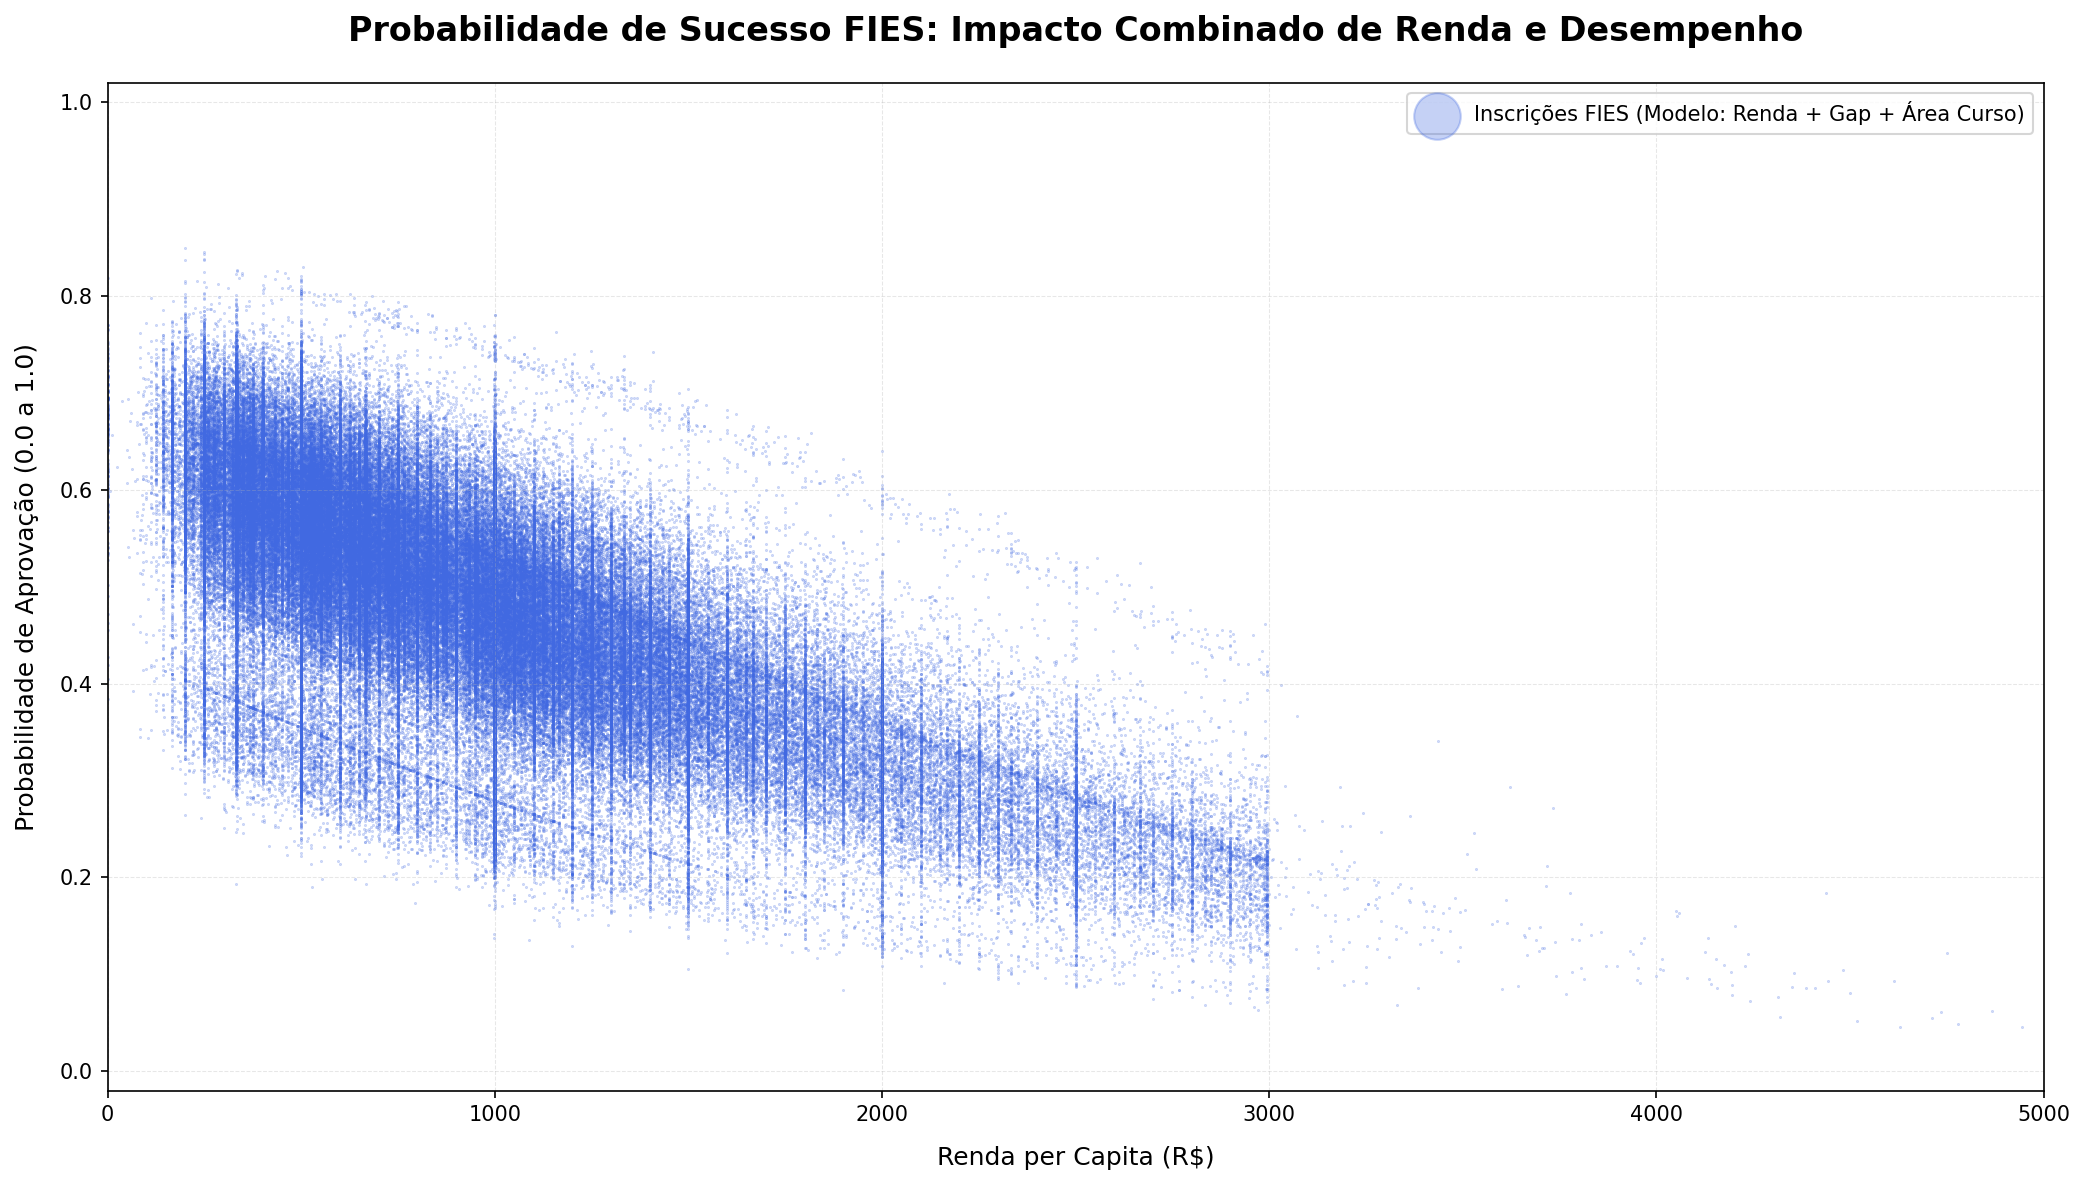

Gráfico Finalizado: 292,147 registros processados com sucesso.


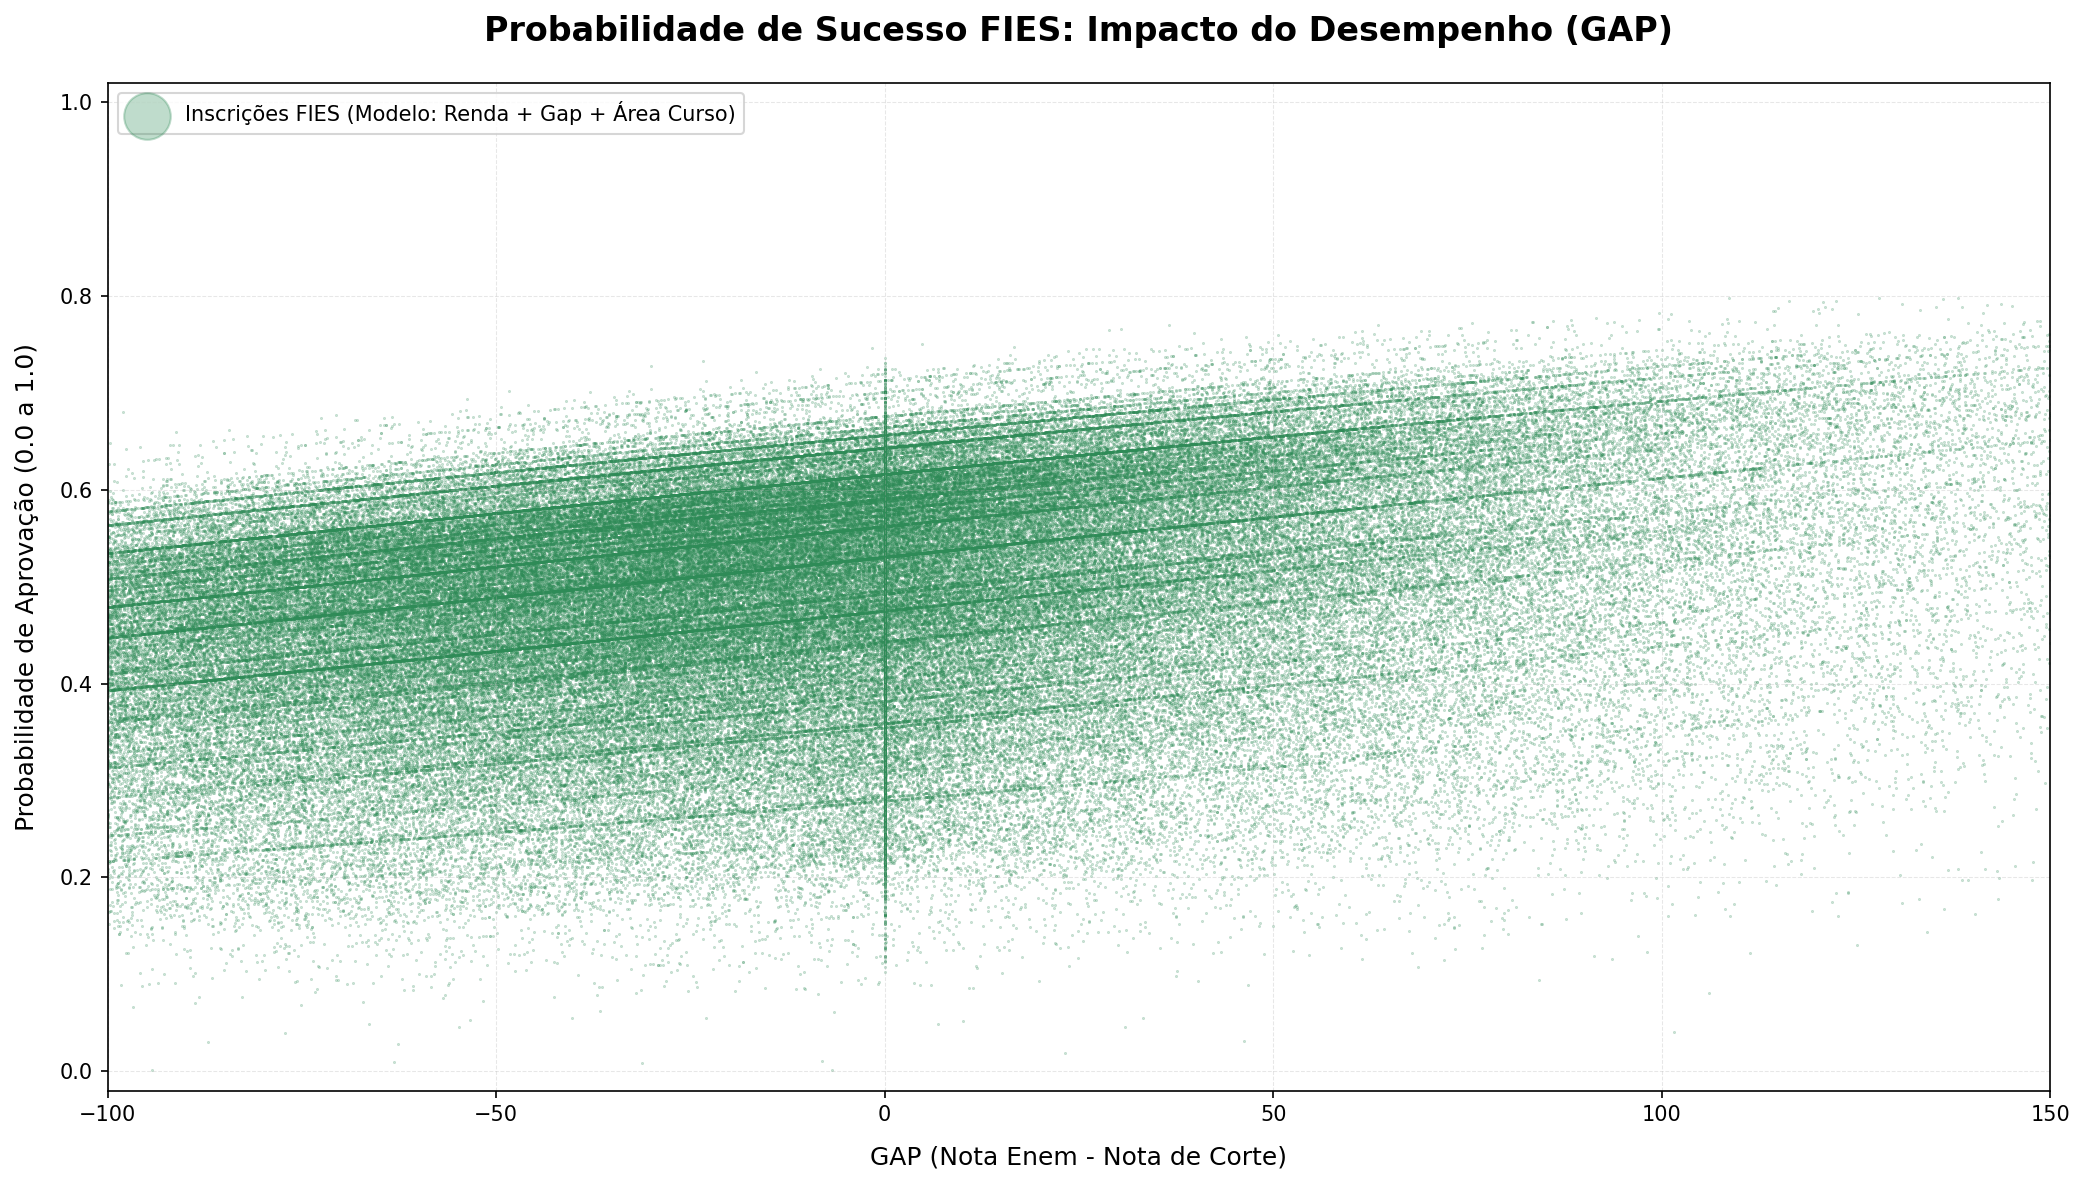

Gráfico Finalizado: 292,147 registros processados com sucesso.
--- Distribuição de Inscritos por Faixa de Renda ---


,faixa_renda,qtd_inscritos,percentual
0,0-500,79586,27.26%
1,501-1000,112616,38.57%
2,1001-1500,62728,21.48%
3,1501-2000,21933,7.51%
4,2001-2500,9797,3.36%
5,2501-3000,5096,1.75%
6,+ de 3001,219,0.08%


--- QUEM MANDA NO FIES? (PESO CORRIGIDO POR ESCALA) ---


,Variável,Impacto Real (Peso Corrigido)
0,renda_per_capita,-0.389020
1,nome_cine_area_geral_Educação,-0.281881
2,"nome_cine_area_geral_Negócios, administração e...",-0.213492
3,gap,0.206332
4,nome_cine_area_geral_Computação e Tecnologias ...,-0.180469
5,"nome_cine_area_geral_Engenharia, produção e co...",-0.137376
6,nome_cine_area_geral_Serviços,-0.130193
7,nome_cine_area_geral_Saúde e bem-estar,-0.126447
8,"nome_cine_area_geral_Ciências sociais, comunic...",-0.120396
9,nome_cine_area_geral_Artes e humanidades,-0.111839


,ano,semestre,nome_cine_area_geral,qtde_de_inscritos
0,2019,1,"Agricultura, silvicultura, pesca e veterinária",14222
1,2019,1,Artes e humanidades,3811
2,2019,1,"Ciências naturais, matemática e estatística",1446
3,2019,1,"Ciências sociais, comunicação e informação",24052
4,2019,1,Computação e Tecnologias da Informação e Comun...,9045
5,2019,1,Educação,14673
6,2019,1,"Engenharia, produção e construção",36208
7,2019,1,"Negócios, administração e direito",87116
8,2019,1,Saúde e bem-estar,148744
9,2019,1,Serviços,5907


------------------------------------------------------------
AVALIAÇÃO DE PERFORMANCE (MÉTRICAS KDD):
Previsões geradas com sucesso!

-> Acurácia Geral do Modelo: 58.07%

------------------------------------------------------------


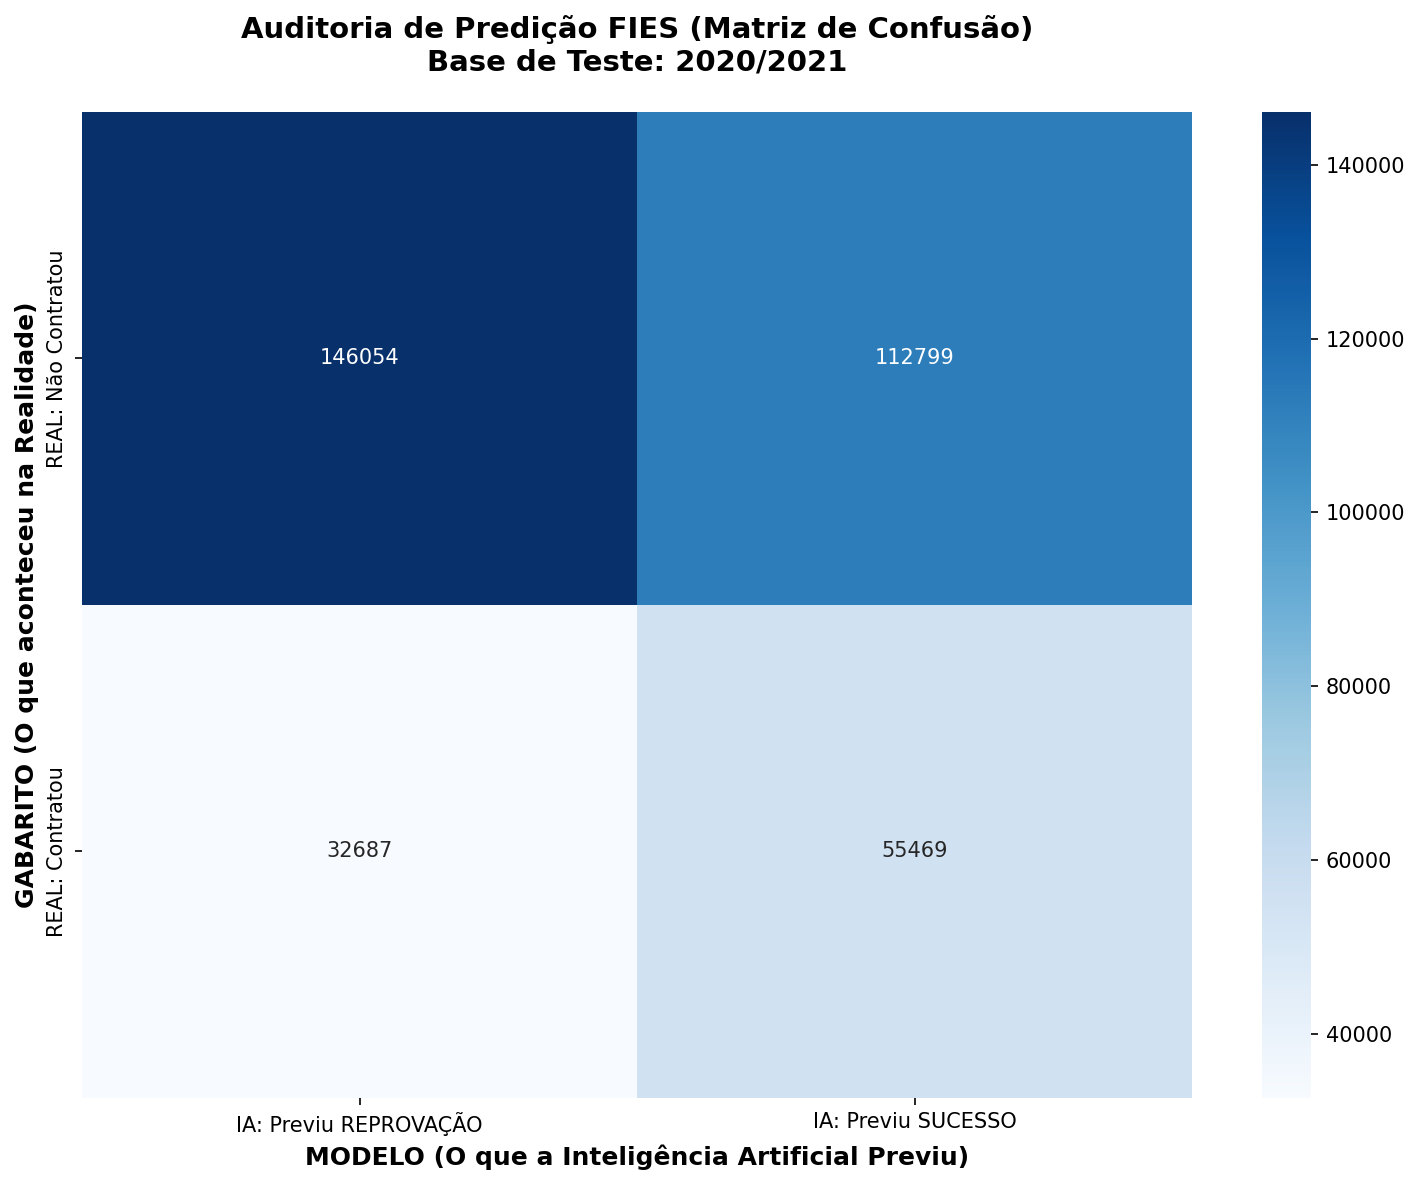


        CONCLUSÕES DO MODELO DE PREDIÇÃO FIES - CANDIDATOS ÚNICOS (VALIDAÇÃO 2019-2021)

        1. DINÂMICA DOS CURSOS (CINE) LIMPA DE RUÍDOS:
        Ao removermos as múltiplas tentativas do mesmo candidato, a área de "Educação" 
        assumiu a maior penalidade estatística (-0.28), seguida por "Negócios, 
        Administração e Direito" (-0.21). A área de "Saúde e bem-estar" apresenta uma 
        barreira menor (-0.12), confirmando que o funil de conversão penaliza mais as 
        áreas de humanas/negócios do que as áreas da saúde.

        2. O PESO DA RENDA ESMAGA O MÉRITO ACADÊMICO:
        Na análise do indivíduo único, a discrepância de pesos ficou ainda mais extrema. 
        A RENDA PER CAPITA saltou para um impacto preditivo de -0.389, enquanto o motor 
        do GAP acadêmico caiu para 0.206. Isso prova matematicamente que a barreira 
        financeira tem quase o dobro do peso do mérito na assinatura do contrato.

        3. A MASSA DE VULNERABILIDADE (RENDA COMO F

In [ ]:
import sys
import pandas as pd
from src.staging import staging_fies, staging_inep
from src.transform_layer_1 import transform_inscritos, transform_ofertas, transform_inep, verificar_colunas_inep
from src.transform_layer_2 import tratar_nans_cine_inscritos, tratar_nans_cine_ofertas
from src.trasnform_layer_3 import processar_modalidades_e_peneira
from src.load import load_inscritos,load_ofertas,auditoria_inscritos_carregados,auditoria_ofertas_carregadas,exportar_para_sqlite
from src.analise_001 import gerar_dataset_candidatos_unicos_por_Prioridade_inicial
from src.analise_002 import eda_gerar_dataset_com_varias_analises
from src.analise_003 import eda_gerar_funil_de_selecao_6_etapas
from src.analise_004 import analise_fuga_cerebros_de_regioes
from src.analise_005 import verificar_qtde_inscritos_por_ano_e_semestre_nacional_e_regional
from src.analise_006 import gerar_dataset_e_grafico_heatmap_quem_sao_os_inscritos_contratados
from src.analise_007 import orquestrador_inicial_inscritos, orquestrador_ja_rodado_inscritos
from src.analise_008 import orquestrador_inicial_candidatos, orquestrador_ja_rodado_candidatos




comando = 'analise'
etapa = '8'

# --- CAMADA: STAGING ---
if comando == "staging":
    staging_fies()
    staging_inep()

# --- CAMADA: TRANSFORM ---
elif comando == "transform":

    if etapa == "1":
        transform_inep()
    elif etapa == "2":
        transform_inscritos()
    elif etapa == "3":
        transform_ofertas()
    elif etapa == "4":
        verificar_colunas_inep()
    elif etapa == "5":
        tratar_nans_cine_inscritos()
    elif etapa == "6":
        tratar_nans_cine_ofertas()
    elif etapa == "7":
        processar_modalidades_e_peneira()
    elif etapa == "all":
        transform_inep()
        transform_inscritos()
        transform_ofertas()
        verificar_colunas_inep()
        tratar_nans_cine_inscritos()
        tratar_nans_cine_ofertas()
        processar_modalidades_e_peneira()

elif comando == "load":

    load_inscritos()
    load_ofertas()
    auditoria_inscritos_carregados()
    auditoria_ofertas_carregadas()
    exportar_para_sqlite()

elif comando == 'analise':

    if etapa == "1":
        gerar_dataset_candidatos_unicos_por_Prioridade_inicial()

    elif etapa == "2":
        eda_gerar_dataset_com_varias_analises()

    elif etapa == "3":
        eda_gerar_funil_de_selecao_6_etapas()

    elif etapa == "4":
        analise_fuga_cerebros_de_regioes()

    elif etapa == "5":
        verificar_qtde_inscritos_por_ano_e_semestre_nacional_e_regional()

    elif etapa == "6":
        gerar_dataset_e_grafico_heatmap_quem_sao_os_inscritos_contratados()

    elif etapa == "7":
        orquestrador_inicial_inscritos()
    
    elif etapa == "7.1":
        orquestrador_ja_rodado_inscritos()

    elif etapa == "8":
        orquestrador_inicial_candidatos()
    
    elif etapa == "8.1":
        orquestrador_ja_rodado_candidatos()